In [1]:
import os 
import sys 
import ipynbname
import fnmatch
from pathlib import Path

import logging
from dotenv import load_dotenv
load_dotenv()

python_dir=os.getenv('python_dir')

if python_dir not in sys.path: 
    print(f"adding {python_dir} to sys path")
    sys.path.append(python_dir)

from common_utils import setup_logger
log_dir=os.getenv('log_dir')
log_file=os.path.join(log_dir, f"{ipynbname.name()}.log")
setup_logger('INFO',log_file)

logging.info(f"start  {ipynbname.name()}")

adding /home/fnz/workspace/serious/aimpro/python to sys path


In [5]:
from pathlib import Path 
from multi_cam_switch.video_composer import Workspace 
workspace =Workspace()
print(workspace.dir)

/mnt/ramdisk/video_composer.py/699


In [8]:
#v1=os.path.join(video_dir, '20260516174010_000001.MP4')
#!ffprobe -v quiet {v1} -print_format json -show_entries stream=index,codec_type:stream_tags=creation_time:format_tags=creation_time

In [9]:

def concat(video_dir, files, output): 
    files=[os.path.join(video_dir, f) for f in files ]
    list_file_name=os.path.join(video_dir, f"{output}.list")
    with open(list_file_name, 'w') as h : 
        for f in files:
            h.write(f"file '{f}' \n")
    output_video=os.path.join(video_dir, f"{output}.MP4")
    txt=  f"ffmpeg -f concat -safe 0 -i {list_file_name} -c copy {output_video}"
    out = ! {txt} 
    print(out[:2])

video_dir="/mnt/c/data/aimpro_raw_video/war-vs-don/left"
video_files=fnmatch.filter(os.listdir(video_dir), "*.MP4")
output='left_all'

concat(video_dir, video_files, output)


['ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers', '  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)']


In [4]:
video_dir="/mnt/c/data/aimpro_raw_video/sample_videos/war-vs-bul/right"
files = ['20260516181403_000006.MP4', '20260516182403_000007.MP4' ]
output='right_h2'

concat(video_dir, files, output)


['ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers', '  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)']


In [11]:
import glob 
files = glob.glob("/mnt/ramdisk/clip_picker.py/13538/**/obj_dection_result.csv", recursive=True)
files 

['/mnt/ramdisk/clip_picker.py/13538/frames_of_video_0/obj_dection_result.csv']

In [20]:
import pandas as pd 
df=pd.read_csv(f"/mnt/ramdisk/clip_picker.py/13538/merged_obj_dection_result.csv", index_col=False)
df.head(5)# 

,ms_rounded,has_baseketball_1,total_num_of_players_1,has_possession_1,total_object_area_1,video_file_1,offset_1,file_name,ms_rounded.1,has_baseketball_0,total_num_of_players_0,has_possession_0,total_object_area_0,video_file_0,offset_0,file_name.1,raw_active_camera_index,active_camera_index
0,0,False,14,True,152091.300781,/mnt/c/data/aimpro_raw_video/sample_videos/war...,39.77,0-0.jpg,0,False,5,False,36373.902344,/mnt/c/data/aimpro_raw_video/sample_videos/war...,0,0-0.jpg,0,0
1,500,False,17,True,217905.570312,/mnt/c/data/aimpro_raw_video/sample_videos/war...,39.77,0-500.jpg,500,False,6,False,45339.443359,/mnt/c/data/aimpro_raw_video/sample_videos/war...,0,0-500.jpg,0,0
2,1000,False,9,False,51139.333984,/mnt/c/data/aimpro_raw_video/sample_videos/war...,39.77,1-0.jpg,1000,False,5,False,33995.619141,/mnt/c/data/aimpro_raw_video/sample_videos/war...,0,1-0.jpg,0,0
3,1500,False,7,False,39073.421875,/mnt/c/data/aimpro_raw_video/sample_videos/war...,39.77,1-500.jpg,1500,False,4,False,24382.047363,/mnt/c/data/aimpro_raw_video/sample_videos/war...,0,1-500.jpg,0,0
4,2000,False,8,False,59036.519531,/mnt/c/data/aimpro_raw_video/sample_videos/war...,39.77,2-0.jpg,2000,False,5,False,34970.379395,/mnt/c/data/aimpro_raw_video/sample_videos/war...,0,2-0.jpg,0,0


In [22]:
import numpy as np 

p=df[['total_num_of_players_0','total_num_of_players_1']].to_numpy()
a=df[['total_object_area_0','total_object_area_1']].to_numpy()

# 1. Find the maximum value in 'c' for each row
p_max = np.max(p, axis=1, keepdims=True)
    
# 2. Create a boolean mask where True means it is a maximum in 'c'
is_p_max = (p == p_max)

masked_a = np.where(is_p_max, a, -np.inf)

res = np.argmax(masked_a, axis=1) 

df['active_camera']=res




In [24]:
def active_camera_index(df): 
            cols = [c for c in df.columns if c.startswith('total_num_of_players_') ]
            cols.sort(key=lambda x:x.split("_")[-1])
            p=df[cols].to_numpy()

            cols = [c for c in df.columns if c.startswith('total_object_area_') ]
            cols.sort(key=lambda x:x.split("_")[-1])
            a=df[cols].to_numpy()

            p_max = np.max(p, axis=1, keepdims=True)
            is_p_max = (p == p_max)
            masked_a = np.where(is_p_max, a, -np.inf)
            return np.argmax(masked_a, axis=1) 
df['active_camera']=active_camera_index(df)
df.active_camera.unique() 


        

array([1, 0])

In [19]:
cols = [c for c in df.columns if c.startswith('total_num_of_players_') ]
cols.sort(key=lambda x:x.split("_")[-1])
cols 
            

['total_num_of_players_0', 'total_num_of_players_1']

<Axes: xlabel='ms'>

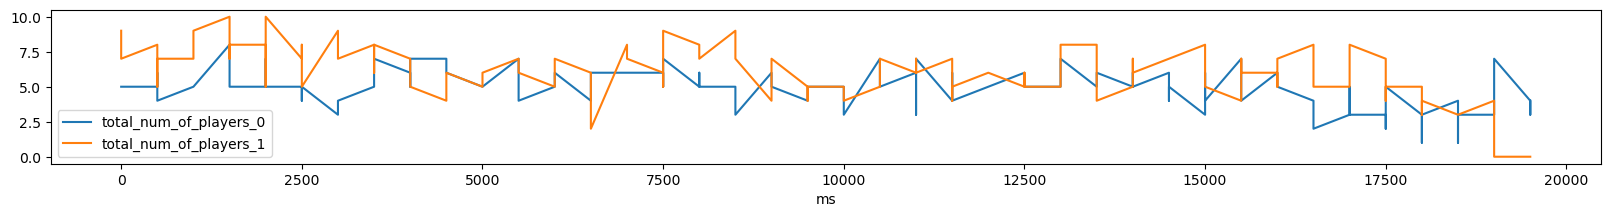

In [9]:
df.head(120).plot(x='ms' , y=['total_num_of_players_0', 'total_num_of_players_1'], kind='line', figsize=(20, 2))

In [ ]:
def agg_to_half_second(df):
    adf=df.groupby('ms').agg(
        {
            "has_baseketball":'any',
            "total_num_of_players":'sum' ,
            "has_possession":'any', 
            "total_object_area":'sum'   
        } 
    ).reset_index()
    adf.sort_values(by='ms', inplace=True)
    return adf 


In [161]:
import numpy as np 
def smooth(s,fps=6 , window_in_seconds=1):
    window_length=fps*window_in_seconds
    window = np.ones(window_length) / window_length 
    ss = np.convolve(s, window, mode='same')
    return pd.Series(ss)
import matplotlib.pyplot as plt
df['smooth_total_players_conf_0']=smooth(df.total_players_conf_0,6,2)
df['smooth_total_players_conf_1']=smooth(df.total_players_conf_1,6,2)


<Axes: xlabel='ms'>

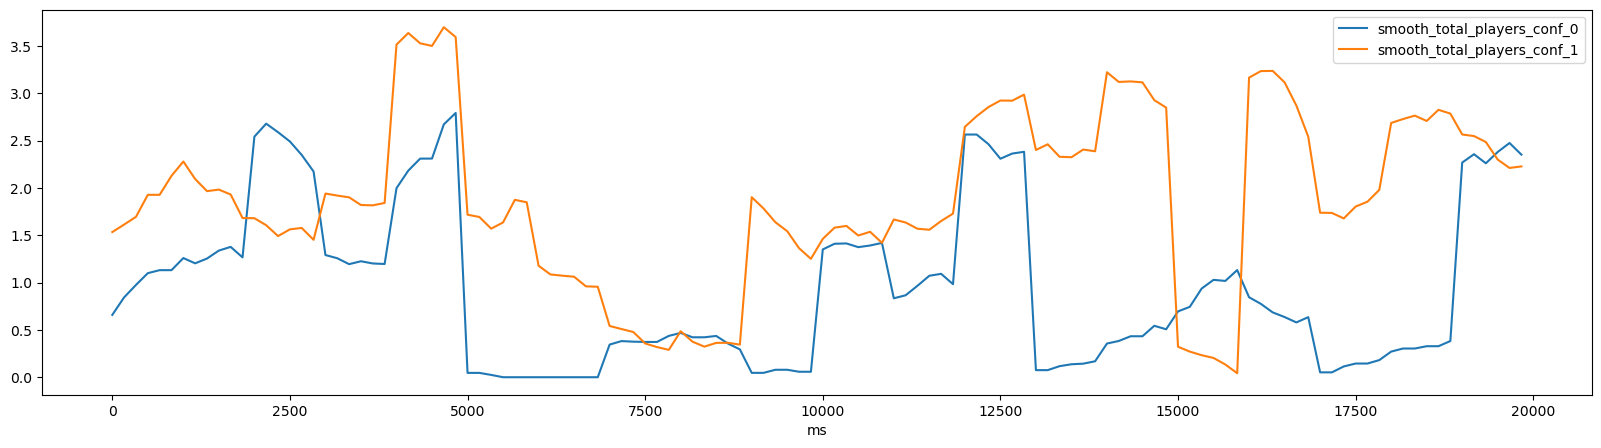

In [163]:
df.head(120).plot(x='ms' , y=['smooth_total_players_conf_0', 'smooth_total_players_conf_1'], kind='line', figsize=(20, 5))

In [223]:
def active_cam_index(df): 
    cols=[c for c in df.columns if c.startswith('total_players_conf_')]
    cols.sort(key=lambda x: x.split("_")[-1])
    m=df[cols].to_numpy()
    return m.argmax(axis=1)
df['raw_active_cam_index']=active_cam_index(df)
df.head(2)

,file_name,video_file_0,offset_0,total_basketball_conf_0,total_players_conf_0,total_posession_conf_0,total_object_area_0,video_file_1,offset_1,total_basketball_conf_1,total_players_conf_1,total_posession_conf_1,total_object_area_1,ms,smooth_total_players_conf_0,smooth_total_players_conf_1,raw_active_cam_index,active_cam_index
0,0-0.jpg,/mnt/c/data/aimpro_raw_video/sample_videos/war...,0,0.0,1.590861,0.0,12760.810547,/mnt/c/data/aimpro_raw_video/sample_videos/war...,39.77,0.0,4.03626,0.0,31319.691406,0,0.658532,1.533319,1,0
1,0-166.jpg,/mnt/c/data/aimpro_raw_video/sample_videos/war...,0,0.0,0.882035,0.0,5784.719238,/mnt/c/data/aimpro_raw_video/sample_videos/war...,39.77,0.0,2.28883,0.0,17471.833984,166,0.843257,1.612339,1,0


In [224]:
def smooth_ac_index(ac_i_s, fps=6, minimum_seconds_to_show=3):
    if  ac_i_s.empty:
        return []
        
    min_sequence_len = fps * minimum_seconds_to_show
    
    # Step 1: Compress array into explicit segments: [{'val': camera_id, 'len': frame_count}, ...]
    segments = []
    curr_val = ac_i_s[0]
    curr_len = 1
    
    for val in ac_i_s[1:]:
        if val == curr_val:
            curr_len += 1
        else:
            segments.append({'val': curr_val, 'len': curr_len})
            curr_val = val
            curr_len = 1
    segments.append({'val': curr_val, 'len': curr_len})
    
    # Step 2: Iteratively resolve segments shorter than the threshold
    changed = True
    while changed:
        changed = False
        for i in range(len(segments)):
            if segments[i]['len'] < min_sequence_len:
                has_left = i > 0
                has_right = i < len(segments) - 1
                
                if has_left and has_right:
                    left_valid = segments[i-1]['len'] >= min_sequence_len
                    right_valid = segments[i+1]['len'] >= min_sequence_len
                    
                    # Rule 1: Prioritise a valid neighbour over an invalid one
                    if left_valid and not right_valid:
                        target_idx = i - 1
                    elif right_valid and not left_valid:
                        target_idx = i + 1
                    else:
                        # Rule 2 & 3: Compare lengths. If equal, tie-break to the left (i-1)
                        if segments[i-1]['len'] >= segments[i+1]['len']:
                            target_idx = i - 1
                        else:
                            target_idx = i + 1
                elif has_left:
                    target_idx = i - 1
                elif has_right:
                    target_idx = i + 1
                else:
                    # Entire array is shorter than the threshold
                    break
                
                # Absorb the short segment's duration into the target neighbour
                segments[target_idx]['len'] += segments[i]['len']
                segments.pop(i)
                
                # Cleanup: Collapse adjacent segments that now share the same value
                j = 0
                while j < len(segments) - 1:
                    if segments[j]['val'] == segments[j+1]['val']:
                        segments[j]['len'] += segments[j+1]['len']
                        segments.pop(j+1)
                    else:
                        j += 1
                        
                changed = True
                break  # Restart scanning loop with updated segments
                
    # Step 3: Reconstruct the flat array from the smoothed segments
    smoothed_ac = []
    for seg in segments:
        smoothed_ac.extend([seg['val']] * seg['len'])
        
    return smoothed_ac
df['active_cam_index']=smooth_ac_index(df.raw_active_cam_index, fps=6, minimum_seconds_to_show=3)

<Axes: xlabel='ms'>

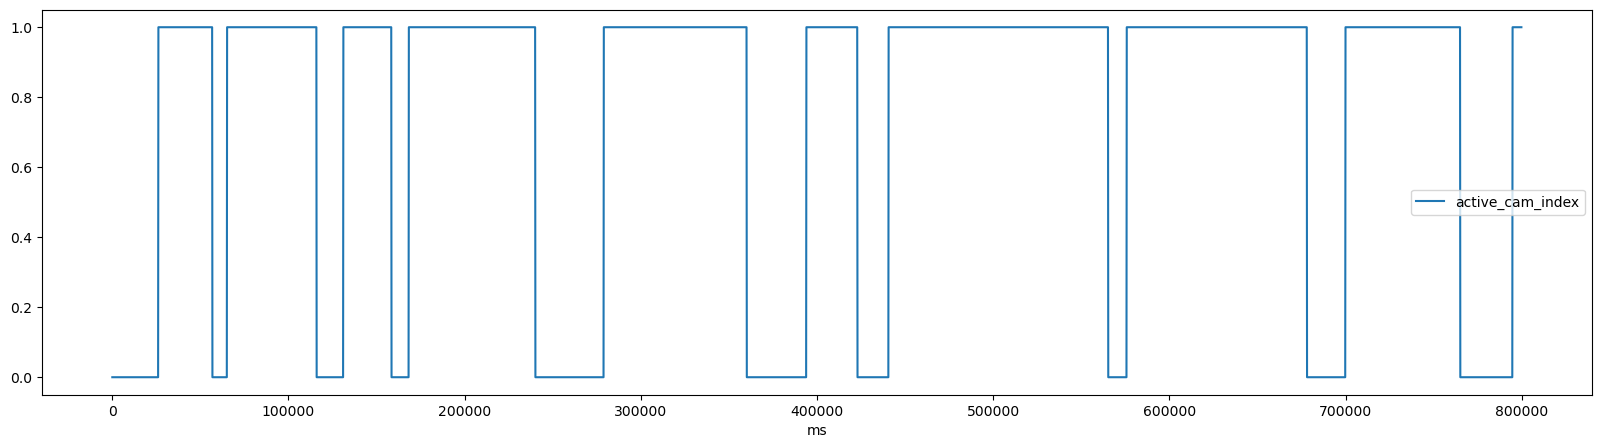

In [225]:
df.head(4800).plot(x='ms' , y=[ 'active_cam_index'], kind='line', figsize=(20, 5))

In [168]:
acdf = pd.read_csv("/mnt/ramdisk/clip_picker.py/9863/active_camera.csv", index_col=False)
acdf.head(2)

,file_name,video_file_0,offset_0,total_basketball_conf_0,total_players_conf_0,total_posession_conf_0,total_object_area_0,video_file_1,offset_1,total_basketball_conf_1,total_players_conf_1,total_posession_conf_1,total_object_area_1,ms,smooth_total_players_conf_0,smooth_total_players_conf_1,raw_active_cam_index,active_cam_index
0,0-0.jpg,/mnt/c/data/aimpro_raw_video/sample_videos/war...,0,0.0,1.590861,0.0,12760.810547,/mnt/c/data/aimpro_raw_video/sample_videos/war...,39.77,0.0,4.03626,0.0,31319.691406,0,0.658532,1.533319,1,1
1,0-166.jpg,/mnt/c/data/aimpro_raw_video/sample_videos/war...,0,0.0,0.882035,0.0,5784.719238,/mnt/c/data/aimpro_raw_video/sample_videos/war...,39.77,0.0,2.28883,0.0,17471.833984,166,0.843257,1.612339,1,1


<Axes: xlabel='ms'>

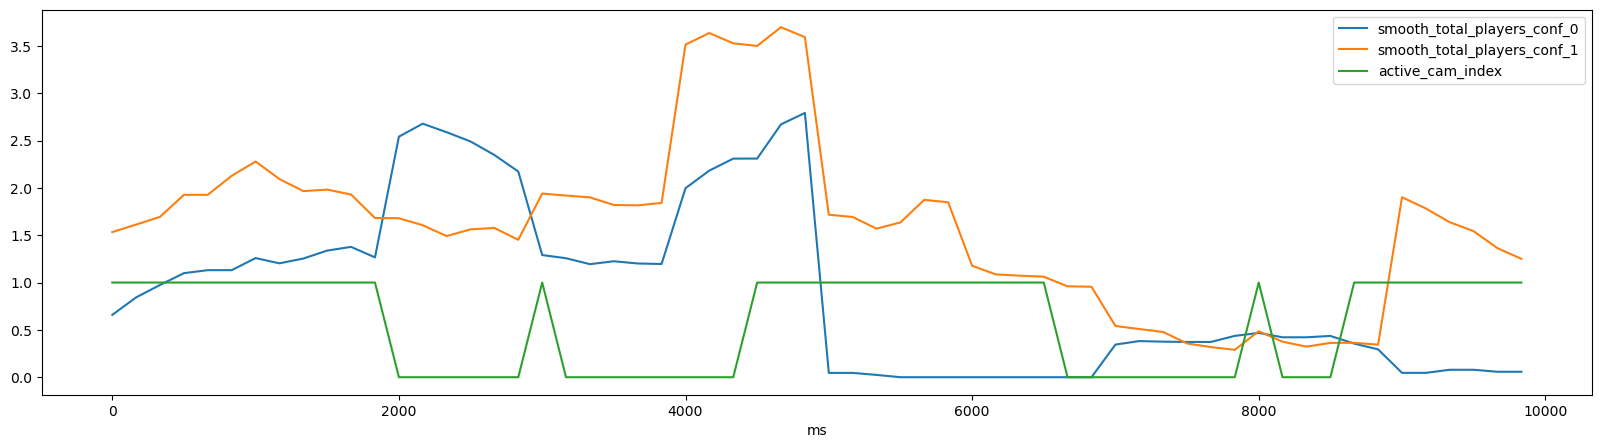

In [179]:
acdf.head(60).plot(x='ms' , y=['smooth_total_players_conf_0', 'smooth_total_players_conf_1', 'active_cam_index'], kind='line', figsize=(20, 5))

In [122]:
mdf = df.merge(acdf, on="ms", how='inner',suffixes=('_x', '_y'))
mdf.shape 

(5161, 35)

In [123]:
mdf.loc[mdf.total_players_conf_1_x!=mdf.total_players_conf_1_y].shape 

(0, 35)

In [124]:
mdf.loc[mdf.smooth_total_players_conf_1_x!=mdf.smooth_total_players_conf_1_y].shape 

(5156, 35)

In [2]:
import pandas as pd 

df=pd.read_csv(f"/mnt/ramdisk/clip_picker.py/2458/merged_obj_dection_result.csv", index_col=False)
df.head(2)# 

,file_name,video_file_0,offset_0,has_baseketball_0,has_possession_0,total_num_of_players_0,total_object_area_0,video_file_1,offset_1,has_baseketball_1,has_possession_1,total_num_of_players_1,total_object_area_1
0,0-0.jpg,/mnt/c/data/aimpro_raw_video/sample_videos/war...,0,False,False,5,31072.378906,/mnt/c/data/aimpro_raw_video/sample_videos/war...,39.77,False,False,9,105371.726562
1,0-166.jpg,/mnt/c/data/aimpro_raw_video/sample_videos/war...,0,False,False,5,26950.441406,/mnt/c/data/aimpro_raw_video/sample_videos/war...,39.77,False,False,7,59944.382812


In [2]:
import numpy as np 

h=np.array(
    [
        [True, True, False], 
        [False, True, False], 
        [False, False, False],
        [False, False, True],
    ]
)
p=np.array(
    [
        [0, 4, 6], 
        [5, 5, 0], 
        [5, 5, 0],
        [2, 5, 3],
    ]
)

a=np.array(
    [
        [0, 30, 80], 
        [60, 40, 0], 
        [70, 20, 0],
        [10, 40, 30],
    ]
)


In [5]:

    # 1. Compute the composite tie-breaker score (A2 + normalized A3)
    a_min = a.min(axis=1, keepdims=True)
    a_max = a.max(axis=1, keepdims=True)
    a_range = a_max - a_min
    a_range[a_range == 0] = 1.0  # Prevent division by zero
        
    a_norm = (a - a_min) / a_range * 0.999999
    combined_score = p.astype(float) + a_norm
    combined_score
    

array([[0.        , 4.37499963, 6.999999  ],
       [5.999999  , 5.666666  , 0.        ],
       [5.999999  , 5.285714  , 0.        ],
       [2.        , 5.999999  , 3.666666  ]])

In [7]:
    
    # 2. Row Classification Masks
    true_counts = h.sum(axis=1)
    mask_exactly_one = (true_counts == 1)
    mask_multiple = (true_counts > 1)
    mask_zero = (true_counts == 0)
    
    mask_exactly_one, mask_multiple, mask_zero

(array([False,  True, False,  True]),
 array([ True, False, False, False]),
 array([False, False,  True, False]))

In [11]:

    # Initialize 1D output array
    M = h.shape[0]
    final_idx = np.zeros(M, dtype=int)
    
    # Tier 1: Exactly One True -> Get its index directly
    if np.any(mask_exactly_one):
        final_idx[mask_exactly_one] = np.argmax(h[mask_exactly_one], axis=1)
        
    # Tier 2: Multiple Trues -> Filter combined_score by A1's True positions, then take argmax
    if np.any(mask_multiple):
        # Mask out combined_score elements where A1 is False by setting them to negative infinity
        filtered_score = np.where(h, combined_score, -np.inf)
        final_idx[mask_multiple] = np.argmax(filtered_score[mask_multiple], axis=1)
        
    # Tier 3: Zero Trues -> Use global argmax of combined_score
    if np.any(mask_zero):
        final_idx[mask_zero] = np.argmax(combined_score[mask_zero], axis=1)
        
    final_idx


array([1, 1, 0, 2])

In [8]:
arr = np.array([10, 25, 30, 45, 50])
indices = np.where(arr > 30)
print(indices)

(array([3, 4]),)


In [9]:
filtered_score = np.where(h, combined_score, -np.inf)
filtered_score

array([[0.        , 4.37499963,       -inf],
       [      -inf, 5.666666  ,       -inf],
       [      -inf,       -inf,       -inf],
       [      -inf,       -inf, 3.666666  ]])

In [10]:
np.argmax(filtered_score[mask_multiple], axis=1)

array([1])

In [ ]:
import numpy as np
from sklearn.cluster import DBSCAN


def filter_static_false_positives(
    detections, min_instances=15, eps_pixels=20
):
    """Filters out stationary false positives from YOLO video detections.

    Args:
        detections (list of dict): A list where each item represents a detection
          with:
            - 'frame': frame index (int)
            - 'bbox': [x1, y1, x2, y2] (list/tuple of floats/ints)
            - 'conf': confidence score (float)
        min_instances (int): Minimum persistent frames to flag as a static FP.
        eps_pixels (int): Maximum pixel distance between box centers to be
          considered the same spot.

    Returns:
        valid_detections (list of dict): Filtered list containing only true
        positives.
        static_clusters (list of dict): Details about the filtered static noise
        zones.
    """
    if not detections:
        return [], []

    # 1. Extract the center coordinates (X, Y) of each bounding box
    centers = []
    for d in detections:
        x1, y1, x2, y2 = d["bbox"]
        cx = (x1 + x2) / 2.0
        cy = (y1 + y2) / 2.0
        centers.append([cx, cy])

    X = np.array(centers)

    # 2. Run DBSCAN clustering based on pixel distance (eps)
    # min_samples is set to min_instances to flag dense clusters immediately
    db = DBSCAN(eps=eps_pixels, min_samples=min_instances).fit(X)
    labels = db.labels_

    valid_detections = []
    static_cluster_centers = []

    # 3. Identify unique clusters (excluding noise label -1)
    unique_labels = set(labels)

    # Calculate centroids of the stationary false positive zones for logging/debugging
    for k in unique_labels:
        if k == -1:
            continue
        cluster_mask = labels == k
        centroid = X[cluster_mask].mean(axis=0)
        static_cluster_centers.append(
            {
                "cluster_id": k,
                "center": centroid.tolist(),
                "count": int(np.sum(cluster_mask)),
            }
        )

    # 4. Filter the original detections
    for idx, label in enumerate(labels):
        # Label -1 means it's a moving object or rare detection (Noise in DBSCAN terms = Good for us)
        # If a cluster exists but doesn't meet our strict criteria, it won't be flagged as a cluster
        if label == -1:
            valid_detections.append(detections[idx])
        else:
            # This detection belongs to a high-density, stationary cluster -> False Positive
            continue

    return valid_detections, static_cluster_centers


# ==========================================
# Example Usage Scenario
# ==========================================
if __name__ == "__main__":
    # Mock data generation
    # Let's simulate a video with 100 frames where a basketball moves,
    # but a stadium light at center (500, 200) is falsely detected every single frame.
    mock_detections = []

    # Simulate Moving Basketball (True Positive)
    for frame in range(100):
        # Ball moves diagonally across the screen
        bx = 100 + (frame * 5)
        by = 150 + (frame * 2)
        mock_detections.append(
            {"frame": frame, "bbox": [bx, by, bx + 30, by + 30], "conf": 0.85}
        )

    # Simulate Stationary Background Glare (False Positive)
    for frame in range(100):
        # Slight pixel jitter (variance) to mimic real neural network outputs
        jitter_x = np.random.randint(-3, 4)
        jitter_y = np.random.randint(-3, 4)
        fx, fy = 500 + jitter_x, 200 + jitter_y
        mock_detections.append(
            {"frame": frame, "bbox": [fx, fy, fx + 25, fy + 25], "conf": 0.72}
        )

    print(f"Total initial detections: {len(mock_detections)}")

    # Apply the filter
    # If an object stays within a 20-pixel radius for more than 30 frames, it's flagged.
    clean_detections, flagged_zones = filter_static_false_positives(
        mock_detections, min_instances=30, eps_pixels=20
    )

    print(f"Clean detections remaining: {len(clean_detections)}")
    print(f"Flagged stationary zones found: {len(flagged_zones)}")
    for zone in flagged_zones:
        print(
            f" -> Removed {zone['count']} frames of static noise at Center Pixel: {zone['center']}"
        )
